# Baseline Experiment Comparison

Compare metrics and dataset scope across `exp_001`, `exp_002`, and `exp_003`.


In [9]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

BASE = Path('../../experiments')
EXPORT_DIR = Path('../../evaluation/tmp/notebook_exports/01_experiment_comparison_data')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

BASE = Path('../../experiments')
EXPORT_DIR_GR = Path('../../evaluation/graphics/')
EXPORT_DIR_GR.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = {
    'exp_001': BASE / 'exp_001_baseline_rent_growth' / 'artifacts',
    'exp_002': BASE / 'exp_002_philly_consistent_baseline' / 'artifacts',
    'exp_003': BASE / 'exp_003_philly_region_zip_panel' / 'artifacts',
}


In [2]:
def load_metrics(exp_name: str, artifacts_dir: Path):
    payload = json.loads((artifacts_dir / 'metrics.json').read_text(encoding='utf-8'))
    if 'holdout' in payload:
        holdout = payload['holdout']; rolling = payload.get('rolling', {}); scope = payload.get('scope', {})
    else:
        holdout = payload; rolling = {}; scope = {}
    rows=[]
    for m in ['naive_lag1','linear_regression']:
        if m in holdout:
            r={'experiment': exp_name, 'model': m}; r.update(holdout[m]); rows.append(r)
    metrics_df = pd.DataFrame(rows)
    split_df = pd.DataFrame([{'experiment': exp_name, **holdout.get('split', {}), **scope}])
    rolling_rows=[]
    for m,v in rolling.get('aggregate', {}).items():
        rolling_rows.append({'experiment': exp_name, 'model': m, **v})
    rolling_df = pd.DataFrame(rolling_rows)
    return metrics_df, split_df, rolling_df


In [3]:
all_m=[]; all_s=[]; all_r=[]; all_ds=[]
for exp,art in EXPERIMENTS.items():
    m,s,r = load_metrics(exp, art); all_m.append(m); all_s.append(s)
    if not r.empty: all_r.append(r)
    ds = art / 'dataset_summary.csv'
    if ds.exists():
        d = pd.read_csv(ds); d.insert(0,'experiment',exp); all_ds.append(d)
holdout_metrics = pd.concat(all_m, ignore_index=True)
split_summary = pd.concat(all_s, ignore_index=True)
rolling_summary = pd.concat(all_r, ignore_index=True) if all_r else pd.DataFrame()
dataset_summary = pd.concat(all_ds, ignore_index=True) if all_ds else pd.DataFrame()

holdout_metrics.to_csv(EXPORT_DIR / 'holdout_metrics_comparison.csv', index=False)
split_summary.to_csv(EXPORT_DIR / 'split_summary_comparison.csv', index=False)
if not rolling_summary.empty: rolling_summary.to_csv(EXPORT_DIR / 'rolling_aggregate_comparison.csv', index=False)
if not dataset_summary.empty: dataset_summary.to_csv(EXPORT_DIR / 'dataset_summary_comparison.csv', index=False)
holdout_metrics


,experiment,model,mae,rmse,directional_accuracy,spearman_corr
0,exp_001,naive_lag1,0.004246,0.005636,0.690714,0.287150
1,exp_001,linear_regression,0.003490,0.004441,0.705000,0.409315
2,exp_002,naive_lag1,0.001965,0.002329,0.800000,0.006061
3,exp_002,linear_regression,0.001663,0.002070,0.900000,0.139394
4,exp_003,naive_lag1,0.012841,0.016136,0.547619,0.070532
5,exp_003,linear_regression,0.009354,0.011940,0.574405,0.132672


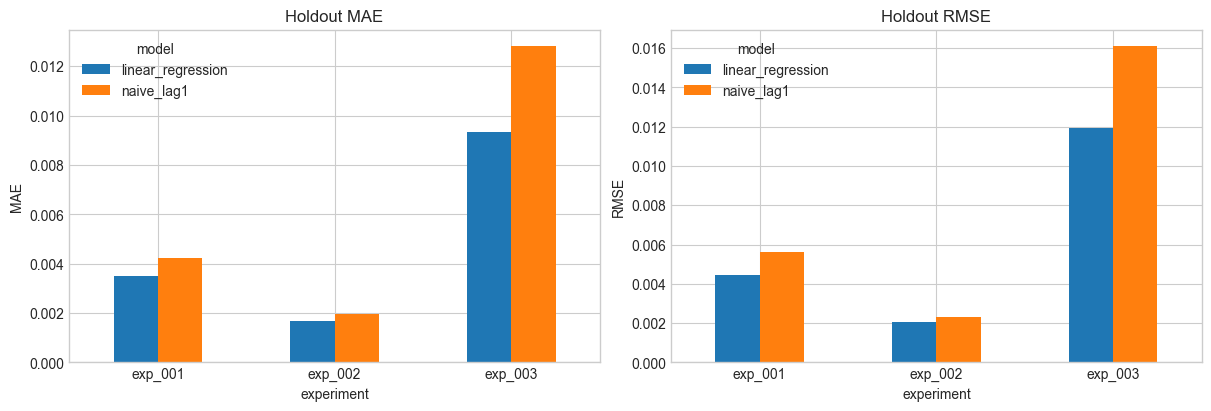

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,4), constrained_layout=True)
for ax,metric,title in [(axes[0],'mae','Holdout MAE'), (axes[1],'rmse','Holdout RMSE')]:
    holdout_metrics.pivot(index='experiment', columns='model', values=metric).plot(kind='bar', ax=ax, rot=0)
    ax.set_ylabel(metric.upper()); ax.set_title(title)
fig.savefig(EXPORT_DIR_GR / 'holdout_error_bars.png', dpi=150, bbox_inches='tight')
plt.show()

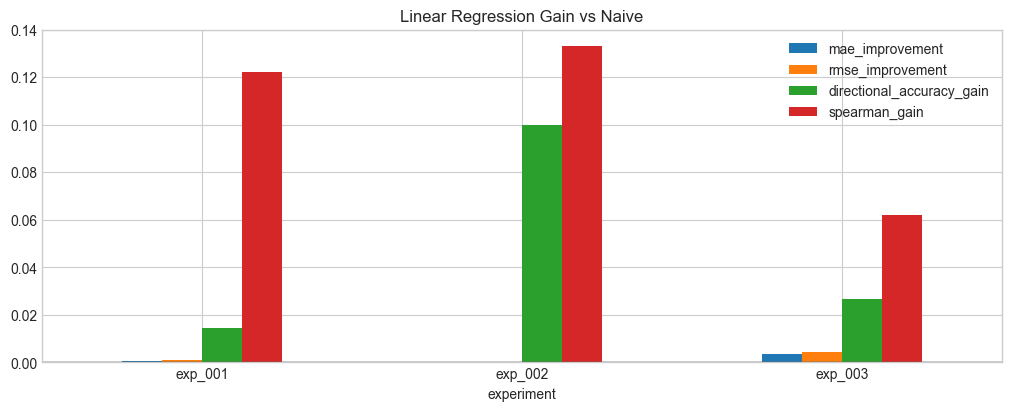

,mae_improvement,rmse_improvement,directional_accuracy_gain,spearman_gain
experiment,,,,
exp_001,0.000756,0.001195,0.014286,0.122164
exp_002,0.000302,0.000259,0.100000,0.133333
exp_003,0.003487,0.004196,0.026786,0.062140


In [11]:
p = holdout_metrics.pivot(index='experiment', columns='model', values=['mae','rmse','directional_accuracy','spearman_corr'])
delta = pd.DataFrame({
    'mae_improvement': p[('mae','naive_lag1')] - p[('mae','linear_regression')],
    'rmse_improvement': p[('rmse','naive_lag1')] - p[('rmse','linear_regression')],
    'directional_accuracy_gain': p[('directional_accuracy','linear_regression')] - p[('directional_accuracy','naive_lag1')],
    'spearman_gain': p[('spearman_corr','linear_regression')] - p[('spearman_corr','naive_lag1')],
})
fig, ax = plt.subplots(figsize=(10,4), constrained_layout=True)
delta.plot(kind='bar', ax=ax, rot=0)
ax.axhline(0.0, color='black', linewidth=1); ax.set_title('Linear Regression Gain vs Naive')
fig.savefig(EXPORT_DIR_GR / 'model_gain_vs_naive.png', dpi=150, bbox_inches='tight')
plt.show()
delta


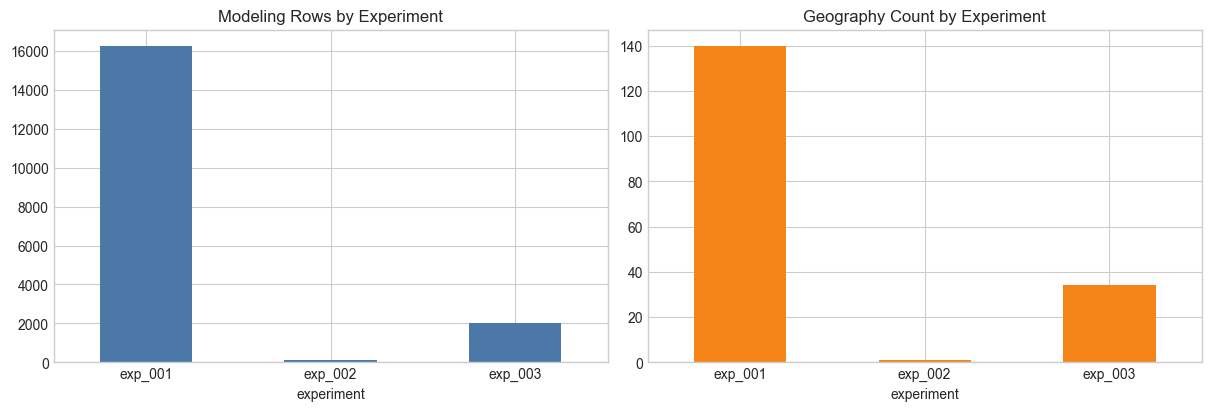

In [12]:
if not dataset_summary.empty and {'experiment','row_count','geo_count'}.issubset(dataset_summary.columns):
    ds = dataset_summary[['experiment','row_count','geo_count']].set_index('experiment')
    fig, axes = plt.subplots(1,2, figsize=(12,4), constrained_layout=True)
    ds['row_count'].plot(kind='bar', ax=axes[0], rot=0, color='#4C78A8'); axes[0].set_title('Modeling Rows by Experiment')
    ds['geo_count'].plot(kind='bar', ax=axes[1], rot=0, color='#F58518'); axes[1].set_title('Geography Count by Experiment')
    fig.savefig(EXPORT_DIR_GR / 'dataset_scope_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('dataset_summary missing row_count/geo_count')
